# End-to-End Time Series Forecasting
## Weekly Beverage Sales by US State

This notebook provides a full walkthrough of:
1. **Data loading & exploration** — parse the Excel, understand distributions
2. **Preprocessing** — handle missing dates, build feature matrix
3. **Model training** — SARIMA, Prophet, XGBoost, LSTM
4. **Model comparison** — RMSE / MAPE on validation window
5. **Forecast visualization** — plot 8-week ahead predictions
6. **API demo** — call the REST API

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('Libraries loaded.')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Libraries loaded.


## 1. Data Loading

In [2]:
from src.data_loader import load_excel, list_states, get_state_series

DATA_PATH = '../../Copy of Forecasting Case- Study.xlsx'
df = load_excel(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'States ({df.state.nunique()}): {list_states(df)[:10]} ...')
df.head()

Shape: (8084, 4)
Columns: ['state', 'date', 'sales', 'category']
States (43): ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Florida', 'Georgia', 'Illinois', 'Indiana'] ...


,state,date,sales,category
0,Alabama,2019-01-12,109574036.0,Beverages
1,Alabama,2019-03-11,112189103.8,Beverages
2,Alabama,2019-06-10,129106730.4,Beverages
3,Alabama,2019-08-12,108083723.8,Beverages
4,Alabama,2019-10-11,110932912.8,Beverages


In [3]:
# Date range
print(f'Date range: {df.date.min().date()} → {df.date.max().date()}')
print(f'\nSales statistics:')
print(df.groupby('state')['sales'].describe().round(0))

Date range: 2019-01-12 → 2023-12-03

Sales statistics:
                count         mean          std          min          25%  \
state                                                                       
Alabama         188.0  159172796.0   39026926.0  104239954.0  124762808.0   
Arizona         188.0  165254610.0   40606820.0  108536780.0  127812779.0   
Arkansas        188.0   83946081.0   20504044.0   55036034.0   64973835.0   
California      188.0  659782261.0  155546599.0  439475032.0  514306846.0   
Colorado        188.0  134379495.0   32384518.0   89816716.0  103988412.0   
Connecticut     188.0   68702692.0   16294620.0   45722598.0   53372213.0   
Florida         188.0  542810862.0  139147789.0  358112986.0  415300645.0   
Georgia         188.0  292766201.0   72165116.0  193036456.0  229225567.0   
Illinois        188.0  241554095.0   58001732.0  165295901.0  187328938.0   
Indiana         188.0  169564645.0   41010620.0  111034723.0  131076744.0   
Iowa            188.0

## 2. Exploratory Data Analysis

Top 5 states by total sales: ['Texas', 'California', 'Florida', 'New York', 'Georgia']


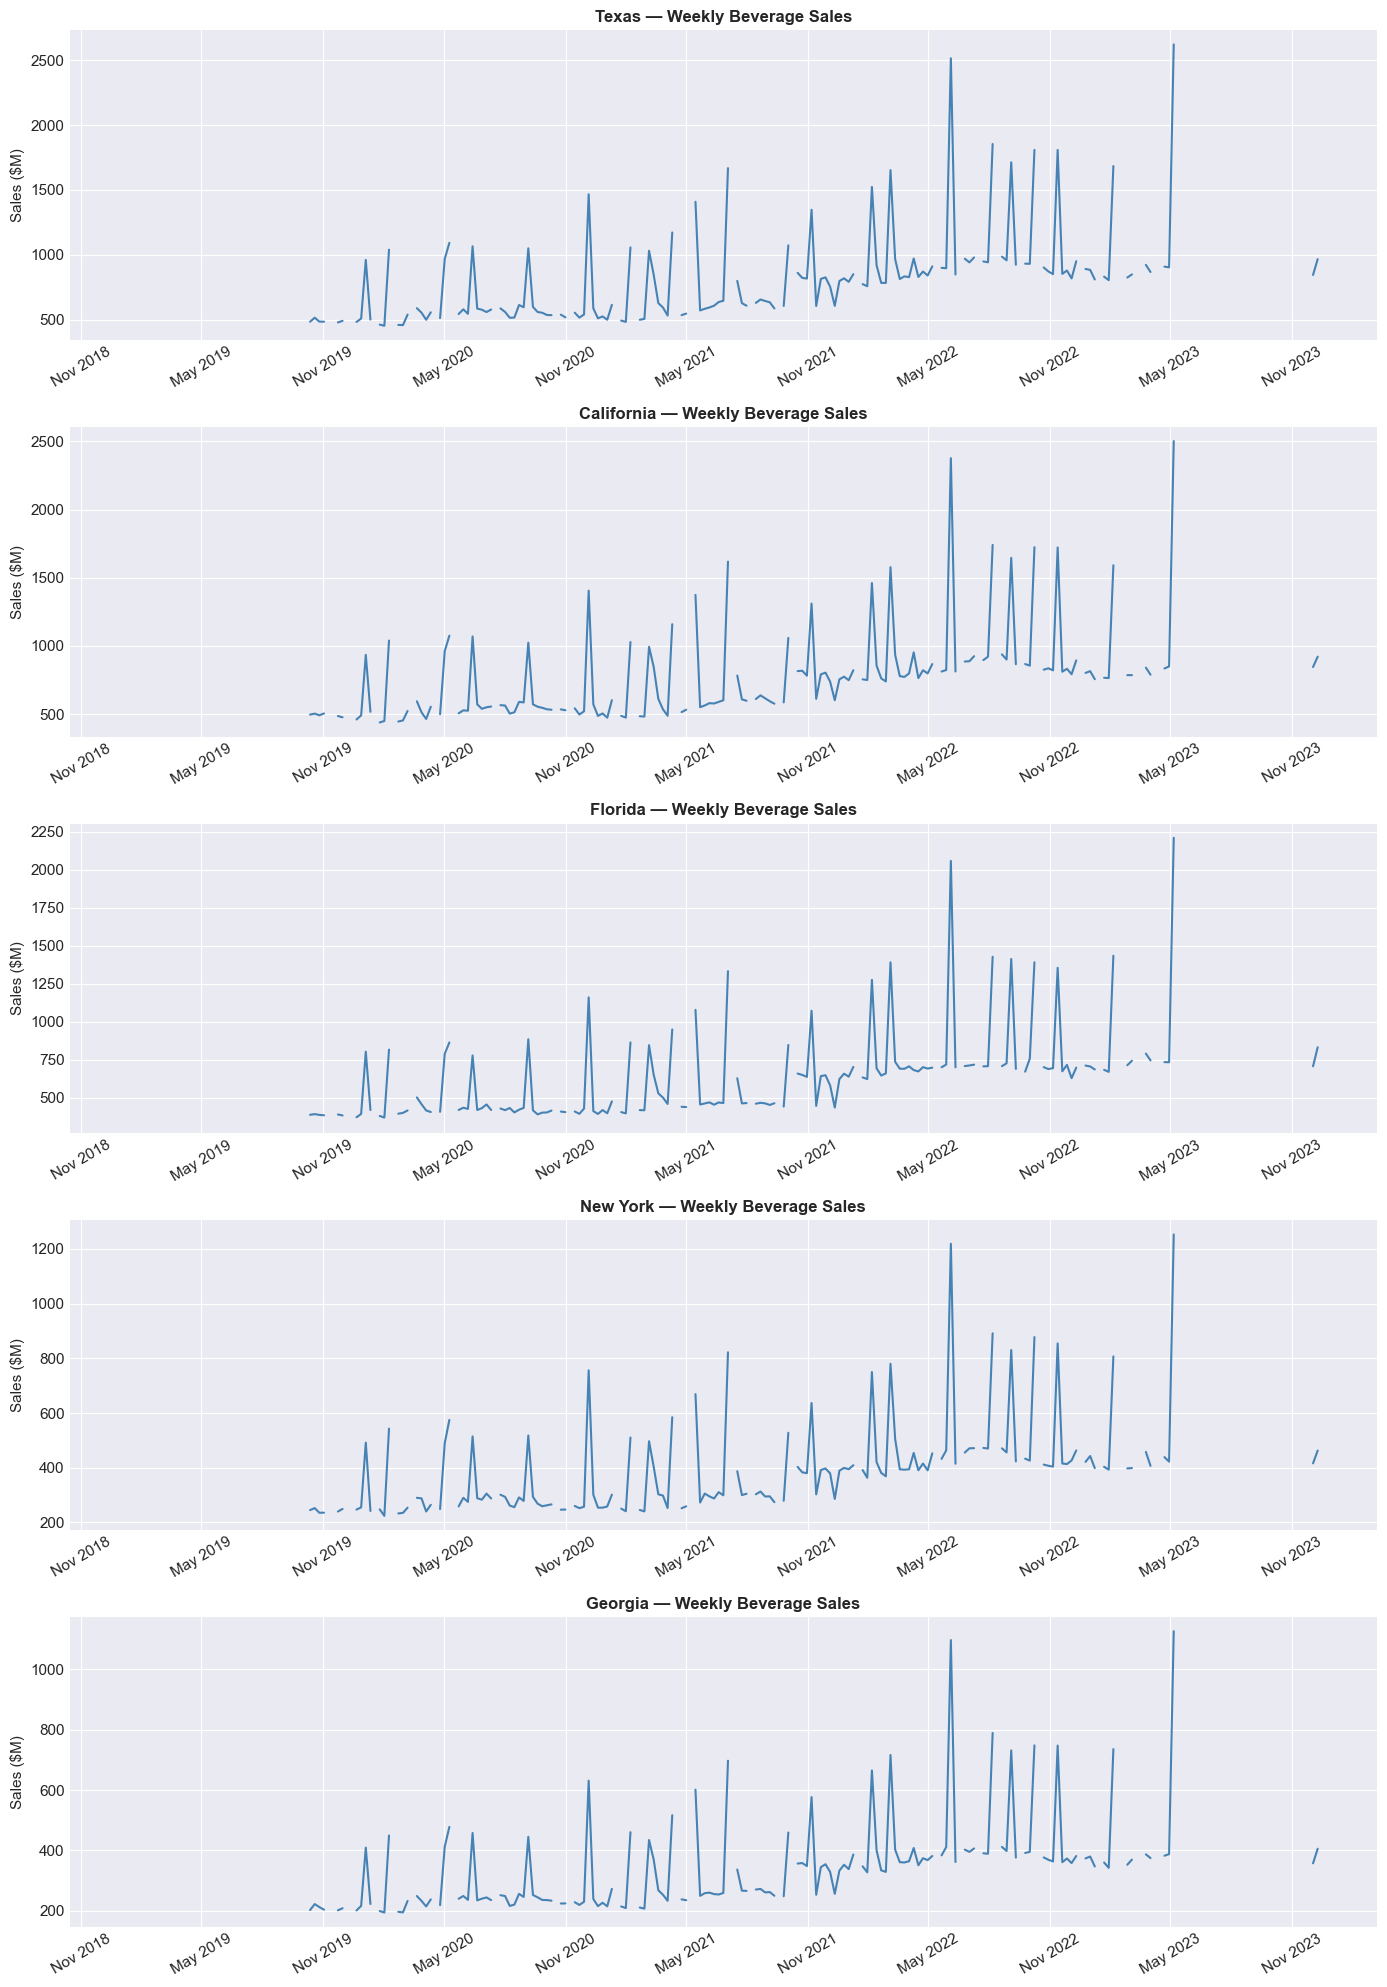

In [4]:
# Top 5 states by total sales
top5 = df.groupby('state')['sales'].sum().nlargest(5).index.tolist()
print('Top 5 states by total sales:', top5)

fig, axes = plt.subplots(len(top5), 1, figsize=(14, 4*len(top5)))
for ax, state in zip(axes, top5):
    series = get_state_series(df, state)
    ax.plot(series.index, series.values / 1e6, color='steelblue', linewidth=1.5)
    ax.set_title(f'{state} — Weekly Beverage Sales', fontsize=12, fontweight='bold')
    ax.set_ylabel('Sales ($M)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('../artifacts/eda_top5_states.png', dpi=120, bbox_inches='tight')
plt.show()

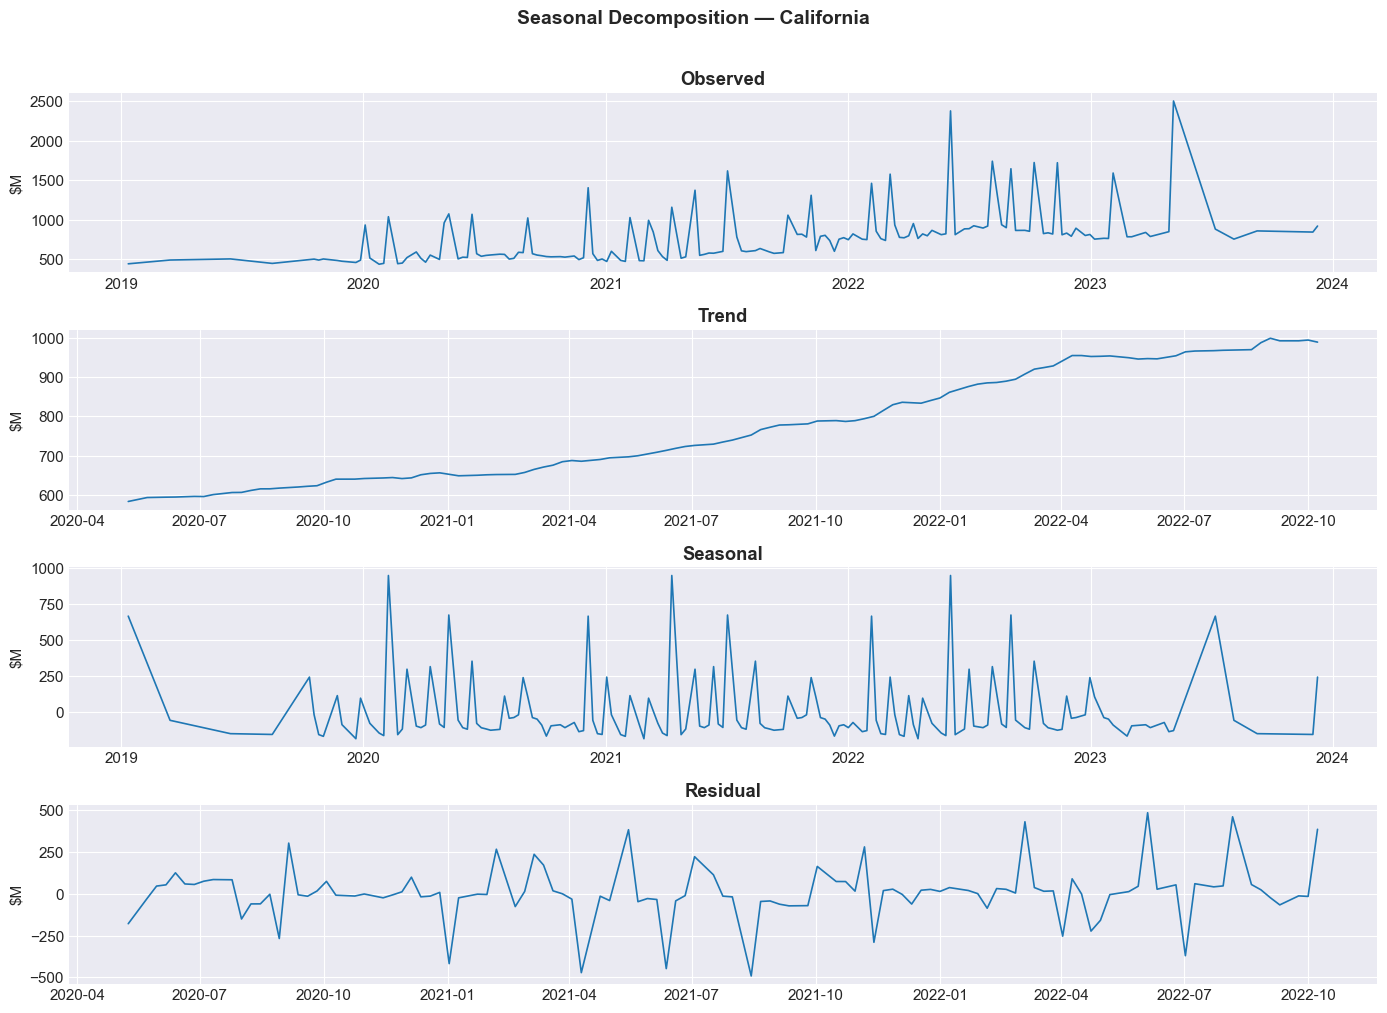

In [5]:
# Seasonal decomposition for California
from statsmodels.tsa.seasonal import seasonal_decompose

state = 'California'
series = get_state_series(df, state).dropna()

decomp = seasonal_decompose(series, model='additive', period=52)
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
for ax, component, label in zip(
    axes,
    [series, decomp.trend, decomp.seasonal, decomp.resid],
    ['Observed', 'Trend', 'Seasonal', 'Residual']
):
    ax.plot(component / 1e6, linewidth=1.2)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('$M')

plt.suptitle(f'Seasonal Decomposition — {state}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../artifacts/eda_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Preprocessing & Feature Engineering

In [6]:
from src.preprocessor import preprocess_state, FEATURE_COLS, VAL_WEEKS

state = 'California'
raw = get_state_series(df, state)
train_df, val_df, filled = preprocess_state(raw)

print(f'Full series: {len(filled)} weeks')
print(f'Train set:   {len(train_df)} weeks  ({train_df.index[0].date()} → {train_df.index[-1].date()})')
print(f'Val set:     {len(val_df)} weeks  ({val_df.index[0].date()} → {val_df.index[-1].date()})')
print(f'\nFeatures ({len(FEATURE_COLS)}):', FEATURE_COLS)
train_df.tail()

Full series: 257 weeks
Train set:   189 weeks  (2020-01-11 → 2023-08-19)
Val set:     16 weeks  (2023-08-26 → 2023-12-09)

Features (15): ['lag_1', 'lag_7', 'lag_30', 'lag_52', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_mean_13', 'week_of_year', 'month', 'quarter', 'year', 'day_of_week', 'is_month_end', 'is_holiday']


,sales,lag_1,lag_7,lag_30,lag_52,rolling_mean_4,rolling_std_4,rolling_mean_8,rolling_mean_13,week_of_year,month,quarter,year,day_of_week,is_month_end,is_holiday
2023-07-22,8.832541e+08,8.832541e+08,2.039207e+09,802540094.2,8.966958e+08,1.056647e+09,2.213480e+08,1.490129e+09,1.623968e+09,29,7,3,2023,5,0,0
2023-07-29,8.199393e+08,8.832541e+08,1.808016e+09,815368628.4,9.215430e+08,9.410517e+08,1.155952e+08,1.316736e+09,1.627663e+09,30,7,3,2023,5,0,0
2023-08-05,7.566245e+08,8.199393e+08,1.576826e+09,756579579.1,1.741007e+09,8.674254e+08,3.165741e+07,1.164328e+09,1.625307e+09,31,8,3,2023,5,0,0
2023-08-12,7.566245e+08,7.566245e+08,1.345635e+09,756579579.1,1.741007e+09,8.357680e+08,6.061933e+07,1.032904e+09,1.491079e+09,32,8,3,2023,5,0,0
2023-08-19,7.566245e+08,7.566245e+08,1.114445e+09,766999016.8,9.383164e+08,8.041106e+08,6.061933e+07,9.303788e+08,1.356851e+09,33,8,3,2023,5,0,0


## 4. Model Training (California example)

In [7]:
# We train each model on California for demonstration
# (production training uses src/trainer.py for all 43 states)

train_series = filled.iloc[:-VAL_WEEKS]
val_series   = filled.iloc[-VAL_WEEKS:]

print(f'Training series: {len(train_series)} weeks')
print(f'Validation:      {len(val_series)} weeks')

Training series: 241 weeks
Validation:      16 weeks


In [8]:
# --- SARIMA ---
from src.models.sarima_model import SarimaModel

sarima = SarimaModel('California', auto_search=False)  # set True for full AIC search
sarima.fit(train_series, train_df)
sarima_metrics = sarima.evaluate(val_series, train_series)
print(f'SARIMA → RMSE: {sarima_metrics["rmse"]:,.0f}  MAPE: {sarima_metrics["mape"]:.2f}%')

SARIMA → RMSE: 288,473,027  MAPE: 33.16%


In [9]:
# --- Prophet ---
from src.models.prophet_model import ProphetModel

prophet = ProphetModel('California', tune_hyperparams=False)
prophet.fit(train_series, train_df)
prophet_metrics = prophet.evaluate(val_series, train_series)
print(f'Prophet → RMSE: {prophet_metrics["rmse"]:,.0f}  MAPE: {prophet_metrics["mape"]:.2f}%')

Importing plotly failed. Interactive plots will not work.
20:43:44 - cmdstanpy - INFO - Chain [1] start processing
20:43:44 - cmdstanpy - INFO - Chain [1] done processing
20:43:44 - cmdstanpy - INFO - Chain [1] start processing
20:43:44 - cmdstanpy - INFO - Chain [1] done processing


Prophet → RMSE: 396,551,373  MAPE: 45.98%


In [10]:
# --- XGBoost ---
from src.models.xgboost_model import XGBoostModel

xgb_model = XGBoostModel('California')
xgb_model.fit(train_series, train_df)
xgb_metrics = xgb_model.evaluate(val_series, train_series)
print(f'XGBoost → RMSE: {xgb_metrics["rmse"]:,.0f}  MAPE: {xgb_metrics["mape"]:.2f}%')

XGBoost → RMSE: 170,796,804  MAPE: 12.85%


In [11]:
# --- LSTM ---
from src.models.lstm_model import LSTMModel

lstm = LSTMModel('California')
lstm.fit(train_series, train_df)
lstm_metrics = lstm.evaluate(val_series, train_series)
print(f'LSTM → RMSE: {lstm_metrics["rmse"]:,.0f}  MAPE: {lstm_metrics["mape"]:.2f}%')

LSTM → RMSE: 141,399,406  MAPE: 14.78%


## 5. Model Comparison

California — Model Comparison
                RMSE MAPE (%)
LSTM     141,399,406   14.78%
XGBoost  170,796,804   12.85%
SARIMA   288,473,027   33.16%
Prophet  396,551,373   45.98%


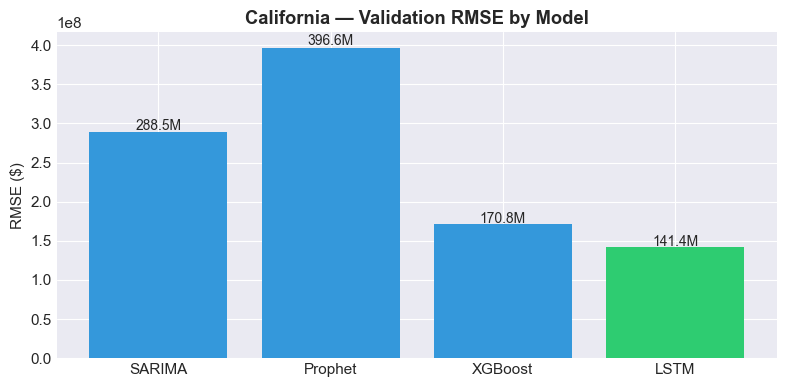

In [12]:
all_metrics = {
    'SARIMA': sarima_metrics,
    'Prophet': prophet_metrics,
    'XGBoost': xgb_metrics,
    'LSTM': lstm_metrics,
}

comp_df = pd.DataFrame(all_metrics).T.rename(columns={'rmse': 'RMSE', 'mape': 'MAPE (%)'})
comp_df = comp_df.sort_values('RMSE')
comp_df['RMSE'] = comp_df['RMSE'].map('{:,.0f}'.format)
comp_df['MAPE (%)'] = comp_df['MAPE (%)'].map('{:.2f}%'.format)
print('California — Model Comparison')
print(comp_df.to_string())

# Bar chart
rmse_vals = {k: v['rmse'] for k, v in all_metrics.items()}
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if k == min(rmse_vals, key=rmse_vals.get) else '#3498db' for k in rmse_vals]
bars = ax.bar(rmse_vals.keys(), rmse_vals.values(), color=colors)
ax.set_title('California — Validation RMSE by Model', fontweight='bold')
ax.set_ylabel('RMSE ($)')
for bar, val in zip(bars, rmse_vals.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{val/1e6:.1f}M', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../artifacts/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Forecast Visualization (next 8 weeks)

Best model: LSTM


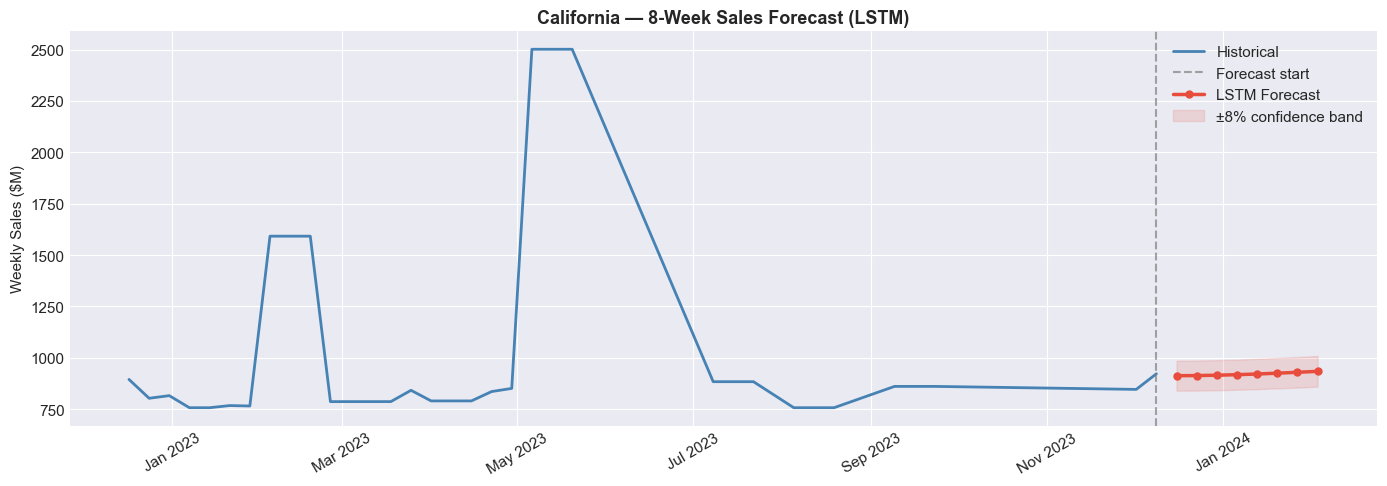


8-Week Forecast:
  2023-12-16  $         912,382,968
  2023-12-23  $         913,080,828
  2023-12-30  $         914,783,029
  2024-01-06  $         917,382,976
  2024-01-13  $         920,722,358
  2024-01-20  $         924,639,700
  2024-01-27  $         928,991,043
  2024-02-03  $         933,658,760


In [13]:
from src.model_selector import select_best

# Pick best model
raw_metrics = {'SARIMA': sarima_metrics, 'Prophet': prophet_metrics,
               'XGBoost': xgb_metrics, 'LSTM': lstm_metrics}
best_name = select_best(raw_metrics)
best_model = {'SARIMA': sarima, 'Prophet': prophet, 'XGBoost': xgb_model, 'LSTM': lstm}[best_name]

print(f'Best model: {best_name}')

# Generate 8-week forecast using full series as history
forecast = best_model.predict(steps=8, last_known=filled)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
recent = filled.tail(52)
ax.plot(recent.index, recent.values / 1e6, label='Historical', color='steelblue', linewidth=2)
ax.axvline(filled.index[-1], color='gray', linestyle='--', alpha=0.7, label='Forecast start')
ax.plot(forecast.index, forecast.values / 1e6,
        label=f'{best_name} Forecast', color='#e74c3c', linewidth=2.5, marker='o', markersize=5)
ax.fill_between(forecast.index,
                forecast.values * 0.92 / 1e6,
                forecast.values * 1.08 / 1e6,
                alpha=0.15, color='#e74c3c', label='±8% confidence band')
ax.set_title(f'California — 8-Week Sales Forecast ({best_name})', fontsize=13, fontweight='bold')
ax.set_ylabel('Weekly Sales ($M)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
plt.tight_layout()
plt.savefig('../artifacts/forecast_california.png', dpi=120, bbox_inches='tight')
plt.show()

# Print forecast table
print('\n8-Week Forecast:')
for date, val in zip(forecast.index, forecast.values):
    print(f'  {date.date()}  ${val:>20,.0f}')

## 7. All-State Model Selection Report

         State Best Model    Val RMSE  Val MAPE (%)
       Alabama    XGBoost  2898643.63          1.28
       Arizona    XGBoost  1271135.25          0.51
      Arkansas    XGBoost  1683451.12          1.52
    California       LSTM  1294672.42          0.15
      Colorado    XGBoost  1393446.27          0.77
   Connecticut    XGBoost   513141.68          0.51
       Florida    XGBoost 12156095.89          1.49
       Georgia    XGBoost  6061675.61          1.30
      Illinois    XGBoost  1098204.27          0.32
       Indiana       LSTM   288308.18          0.13
          Iowa    XGBoost   729207.30          0.59
        Kansas    XGBoost   737652.61          0.77
      Kentucky    XGBoost  2085413.79          1.18
     Louisiana    XGBoost  1302894.98          0.70
         Maine       LSTM   538451.81          1.12
      Maryland    XGBoost   940733.17          0.55
 Massachusetts       LSTM   179917.82          0.10
      Michigan    XGBoost  1876423.86          0.61
     Minneso

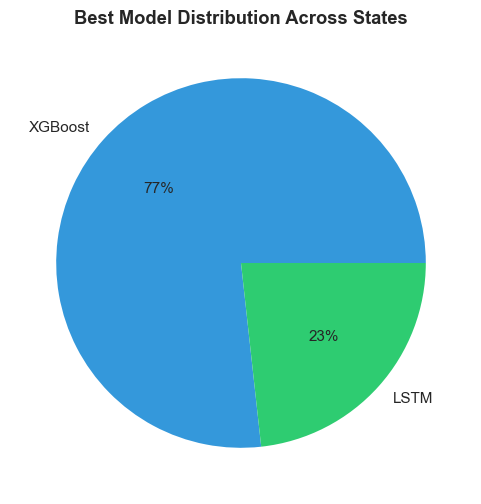

In [14]:
# Load the report generated by setup.py / src/trainer.py
import json
from pathlib import Path

report_path = Path('../artifacts/best_models.json')
if report_path.exists():
    with open(report_path) as f:
        report = json.load(f)

    rows = []
    for state, r in sorted(report.items()):
        best = r['best_model']
        m = r['metrics'][best]
        rows.append({'State': state, 'Best Model': best,
                     'Val RMSE': m['rmse'], 'Val MAPE (%)': m['mape']})

    summary = pd.DataFrame(rows)
    print(summary.to_string(index=False))

    # Model distribution pie
    model_counts = summary['Best Model'].value_counts()
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.pie(model_counts.values, labels=model_counts.index, autopct='%1.0f%%',
           colors=['#3498db','#2ecc71','#e74c3c','#9b59b6'])
    ax.set_title('Best Model Distribution Across States', fontweight='bold')
    plt.savefig('../artifacts/model_distribution.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('No report found. Run: python setup.py --skip-lstm --fast')

## 8. API Demo

In [15]:
# Start the API first: uvicorn api.main:app --reload
# Then run this cell

import requests

BASE = 'http://localhost:8000/api/v1'

# Health check
r = requests.get(f'{BASE}/health')
print('Health:', r.json())

# List states
states = requests.get(f'{BASE}/states').json()
print(f'\nAvailable states ({len(states)}):', states[:5], '...')

# Forecast via GET
r = requests.get(f'{BASE}/forecast/California?weeks=8')
result = r.json()
print(f"\nCalifornia forecast using {result['model_used']} (RMSE={result['val_rmse']:,.0f})")
for p in result['predictions']:
    print(f"  {p['date']}  ${p['sales']:>20,.0f}")

# Forecast via POST
r = requests.post(f'{BASE}/forecast', json={'state': 'Texas', 'weeks': 4})
print('\nTexas (POST):', r.json())

Health: {'status': 'ok', 'total_states_trained': 43, 'message': 'Forecasting API is live. 43 states ready.'}

Available states (43): ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado'] ...

California forecast using LSTM (RMSE=1,294,672)
  2023-12-16  $         860,002,821
  2023-12-23  $         861,690,001
  2023-12-30  $         863,148,516
  2024-01-06  $         864,424,765
  2024-01-13  $         865,570,908
  2024-01-20  $         866,629,495
  2024-01-27  $         867,634,165
  2024-02-03  $         868,610,408

Texas (POST): {'state': 'Texas', 'model_used': 'XGBoost', 'val_rmse': 8691781.96, 'val_mape': 0.91, 'train_end': '2023-08-12', 'forecast_start': '2023-12-16', 'forecast_end': '2024-01-06', 'predictions': [{'date': '2023-12-16', 'sales': 850101760.0}, {'date': '2023-12-23', 'sales': 946916416.0}, {'date': '2023-12-30', 'sales': 858651776.0}, {'date': '2024-01-06', 'sales': 935219456.0}]}
